# NB03: Sampling Bias Characterisation

Is sampling in the target domain weather-dependent? Quantify and correct for sampling bias.

In [1]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
import warnings
warnings.filterwarnings('ignore')

DATA_DIR = '/Users/dlau/repos/fish-welfare/data/'
OUT_DIR = '/Users/dlau/repos/fish-welfare/ModelSelection/'
print("Imports OK")

Imports OK


## 1. Load Weather & Define Calendar Days

In [2]:
meteo = pd.read_csv(DATA_DIR + 'open_meteo_24.csv')
meteo['time'] = pd.to_datetime(meteo['time'])
meteo = meteo[meteo['region'] == 'Eluru'].copy()
meteo['date'] = pd.to_datetime(meteo['time'].dt.date)
meteo['hour'] = meteo['time'].dt.hour

# Daily weather summaries
daily_wx = meteo.groupby('date').agg(
    temp_mean=('temperature_2m','mean'),
    temp_max=('temperature_2m','max'),
    rh_mean=('relative_humidity_2m','mean'),
    precip_sum=('precipitation','sum'),
    wind_mean=('wind_speed_10m','mean'),
    vpd_mean=('vapor_pressure_deficit','mean'),
    sw_sum=('shortwave_radiation','sum'),
).reset_index()

print("Daily weather shape:", daily_wx.shape)
print("Date range:", daily_wx['date'].min(), "to", daily_wx['date'].max())

Daily weather shape: (1707, 8)
Date range: 2021-06-15 00:00:00 to 2026-02-15 00:00:00


## 2. Mark Sampled Days

In [3]:
wq = pd.read_csv(DATA_DIR + 'water_quality.csv')
target_wq = wq[
    (wq['region'] == 'Eluru') &
    (wq['Type'] == 'Morning') &
    (wq['Is follow up'] == 'No')
].copy()
target_wq['date'] = pd.to_datetime(target_wq['Date of data collection'], format='%m/%d/%Y')
target_wq['DO'] = pd.to_numeric(target_wq['DO (mg/L)'], errors='coerce')

sampled_dates = set(target_wq['date'].dt.date)

# Restrict to overlapping period
start_date = target_wq['date'].min()
end_date = target_wq['date'].max()
print(f"Target observation period: {start_date.date()} to {end_date.date()}")

daily_wx_period = daily_wx[(daily_wx['date'] >= start_date) & (daily_wx['date'] <= end_date)].copy()
daily_wx_period['sampled'] = daily_wx_period['date'].dt.date.isin(sampled_dates).astype(int)

print(f"Calendar days in period: {len(daily_wx_period)}")
print(f"Sampled days: {daily_wx_period['sampled'].sum()}")
print(f"Sampling rate: {daily_wx_period['sampled'].mean():.3f}")

Target observation period: 2021-07-12 to 2026-01-27
Calendar days in period: 1661
Sampled days: 746
Sampling rate: 0.449


## 3. Logistic Regression: sampled_day ~ weather features

In [4]:
features = ['temp_mean','rh_mean','precip_sum','wind_mean','vpd_mean','sw_sum']
X_df = daily_wx_period[features].copy()
X_df = (X_df - X_df.mean()) / X_df.std()
X_df = sm.add_constant(X_df)
y = daily_wx_period['sampled']

logit_model = sm.Logit(y, X_df).fit(disp=False)
print(logit_model.summary())
print("\nOdds Ratios (exp(coef)):")
print(np.exp(logit_model.params).round(3))

                           Logit Regression Results                           
Dep. Variable:                sampled   No. Observations:                 1661
Model:                          Logit   Df Residuals:                     1654
Method:                           MLE   Df Model:                            6
Date:                Fri, 24 Apr 2026   Pseudo R-squ.:                 0.01452
Time:                        22:34:14   Log-Likelihood:                -1126.1
converged:                       True   LL-Null:                       -1142.7
Covariance Type:            nonrobust   LLR p-value:                 9.678e-06
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.2142      0.050     -4.280      0.000      -0.312      -0.116
temp_mean      0.1102      0.114      0.967      0.333      -0.113       0.333
rh_mean       -0.4417      0.241     -1.836      0.0

## 4. Weather Distributions: Sampled vs Non-Sampled Days

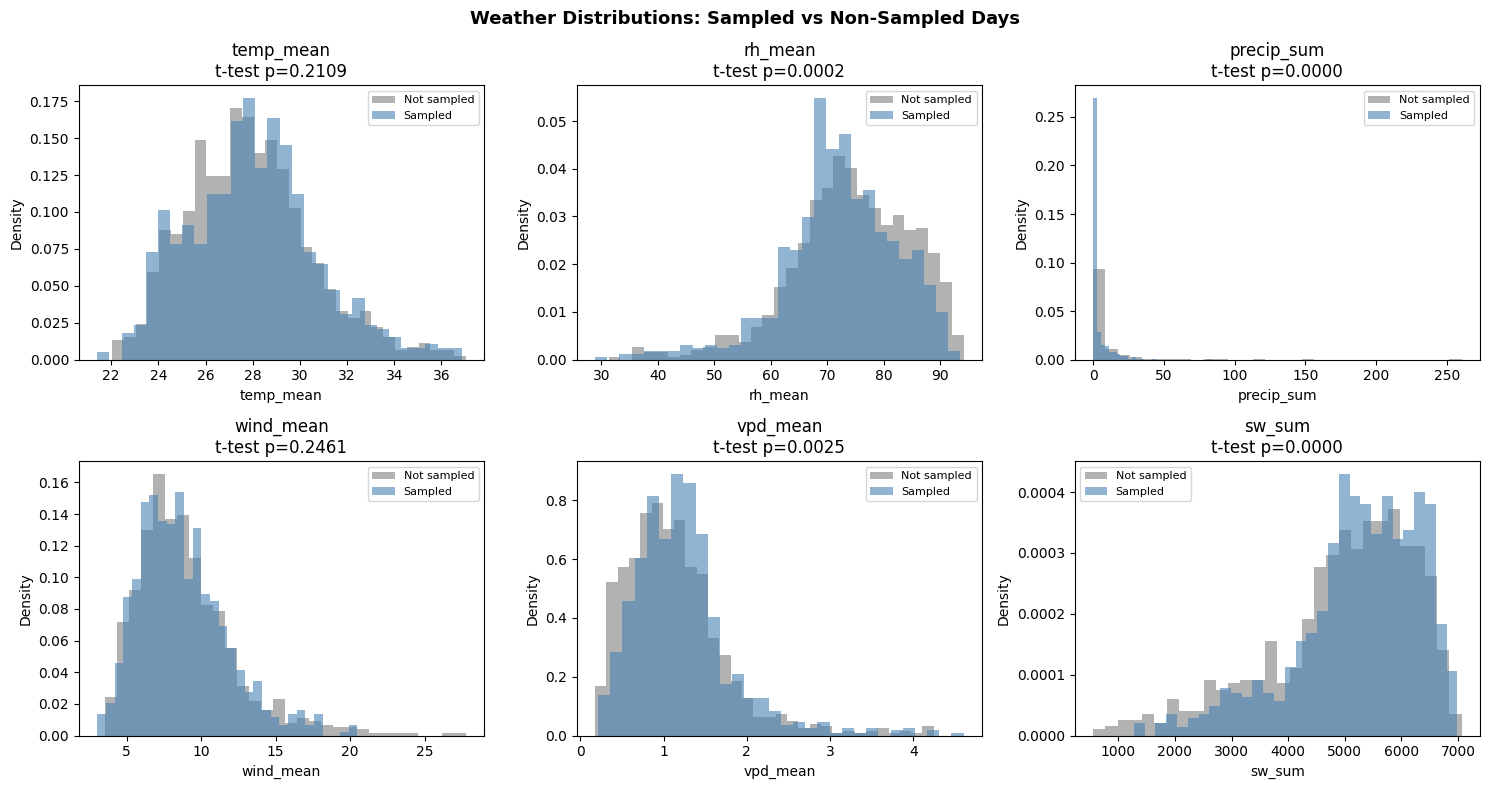


t-test results (sampled vs non-sampled days):
   feature  t_stat  p_val  sampled_mean  unsampled_mean
 temp_mean   1.251 0.2109        28.013          27.848
   rh_mean  -3.790 0.0002        72.179          74.139
precip_sum  -4.245 0.0000         3.041           5.422
 wind_mean  -1.160 0.2461         8.793           8.977
  vpd_mean   3.026 0.0025         1.236           1.142
    sw_sum   4.579 0.0000      5236.976        4961.645


In [5]:
sampled = daily_wx_period[daily_wx_period['sampled']==1]
not_sampled = daily_wx_period[daily_wx_period['sampled']==0]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

ttest_results = []
for i, feat in enumerate(features):
    ax = axes[i]
    s_vals = sampled[feat].dropna()
    n_vals = not_sampled[feat].dropna()
    ax.hist(n_vals, bins=30, alpha=0.6, density=True, color='gray', label='Not sampled')
    ax.hist(s_vals, bins=30, alpha=0.6, density=True, color='steelblue', label='Sampled')
    t_stat, t_p = stats.ttest_ind(s_vals, n_vals)
    ax.set_title(f"{feat}\nt-test p={t_p:.4f}")
    ax.legend(fontsize=8)
    ax.set_xlabel(feat)
    ax.set_ylabel('Density')
    ttest_results.append({'feature': feat, 't_stat': round(t_stat,3), 'p_val': round(t_p,4),
                          'sampled_mean': round(s_vals.mean(),3), 'unsampled_mean': round(n_vals.mean(),3)})

plt.suptitle('Weather Distributions: Sampled vs Non-Sampled Days', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(OUT_DIR + 'nb03_sampling_weather_bias.png', dpi=80, bbox_inches='tight')
plt.show()

ttest_df = pd.DataFrame(ttest_results)
print("\nt-test results (sampled vs non-sampled days):")
print(ttest_df.to_string(index=False))

## 5. Temporal Bias: Sampling by Month/Year

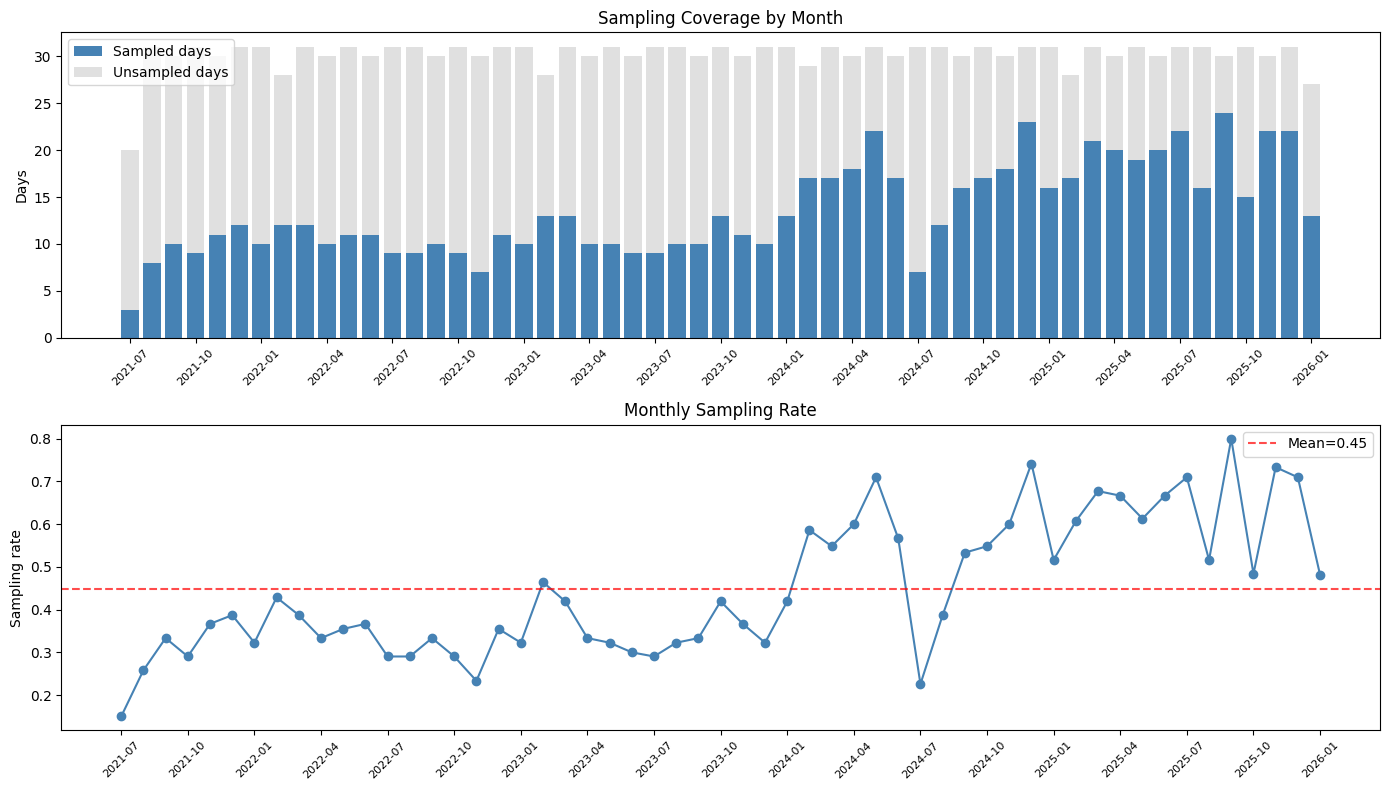

Sampling rate stats:
count    55.000
mean      0.448
std       0.160
min       0.150
25%       0.323
50%       0.387
75%       0.576
max       0.800
Name: sampling_rate, dtype: float64


In [6]:
daily_wx_period['year'] = daily_wx_period['date'].dt.year
daily_wx_period['month'] = daily_wx_period['date'].dt.month
daily_wx_period['year_month'] = daily_wx_period['date'].dt.to_period('M')

monthly = daily_wx_period.groupby('year_month').agg(
    total_days=('sampled','count'),
    sampled_days=('sampled','sum')
).reset_index()
monthly['sampling_rate'] = monthly['sampled_days'] / monthly['total_days']

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

ax = axes[0]
ax.bar(range(len(monthly)), monthly['sampled_days'], label='Sampled days', color='steelblue')
ax.bar(range(len(monthly)), monthly['total_days'] - monthly['sampled_days'], 
       bottom=monthly['sampled_days'], label='Unsampled days', color='lightgray', alpha=0.7)
ax.set_xticks(range(0, len(monthly), 3))
ax.set_xticklabels([str(m) for m in monthly['year_month'][::3]], rotation=45, fontsize=8)
ax.set_ylabel('Days')
ax.set_title('Sampling Coverage by Month')
ax.legend()

ax = axes[1]
ax.plot(range(len(monthly)), monthly['sampling_rate'], 'o-', color='steelblue')
ax.axhline(monthly['sampling_rate'].mean(), color='red', linestyle='--', alpha=0.7, label=f'Mean={monthly["sampling_rate"].mean():.2f}')
ax.set_xticks(range(0, len(monthly), 3))
ax.set_xticklabels([str(m) for m in monthly['year_month'][::3]], rotation=45, fontsize=8)
ax.set_ylabel('Sampling rate')
ax.set_title('Monthly Sampling Rate')
ax.legend()

plt.tight_layout()
plt.savefig(OUT_DIR + 'nb03_temporal_sampling_bias.png', dpi=80, bbox_inches='tight')
plt.show()
print("Sampling rate stats:")
print(monthly['sampling_rate'].describe().round(3))

## 6. Pond Selection Bias

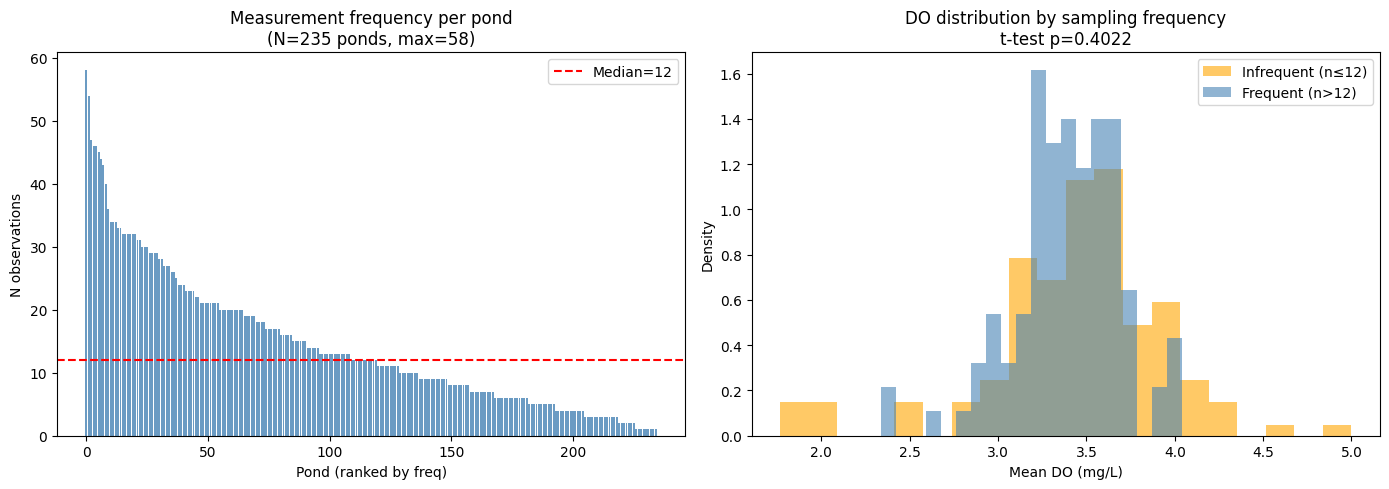

In [7]:
pond_counts = target_wq.groupby('pond_id').agg(
    n_obs=('DO','count'),
    mean_do=('DO','mean')
).reset_index().sort_values('n_obs', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.bar(range(len(pond_counts)), pond_counts['n_obs'].values, color='steelblue', alpha=0.8)
ax.set_xlabel('Pond (ranked by freq)')
ax.set_ylabel('N observations')
ax.set_title(f'Measurement frequency per pond\n(N={len(pond_counts)} ponds, max={pond_counts["n_obs"].max()})')
ax.axhline(pond_counts['n_obs'].median(), color='red', linestyle='--', label=f'Median={pond_counts["n_obs"].median():.0f}')
ax.legend()

ax = axes[1]
freq_median = pond_counts['n_obs'].median()
frequent = pond_counts[pond_counts['n_obs'] > freq_median]['mean_do']
infrequent = pond_counts[pond_counts['n_obs'] <= freq_median]['mean_do']
ax.hist(infrequent.dropna(), bins=20, alpha=0.6, density=True, color='orange', label=f'Infrequent (n≤{freq_median:.0f})')
ax.hist(frequent.dropna(), bins=20, alpha=0.6, density=True, color='steelblue', label=f'Frequent (n>{freq_median:.0f})')
t_stat, p = stats.ttest_ind(frequent.dropna(), infrequent.dropna())
ax.set_title(f'DO distribution by sampling frequency\nt-test p={p:.4f}')
ax.set_xlabel('Mean DO (mg/L)')
ax.set_ylabel('Density')
ax.legend()

plt.tight_layout()
plt.savefig(OUT_DIR + 'nb03_pond_selection_bias.png', dpi=80, bbox_inches='tight')
plt.show()

## 7. Morning Timing Bias

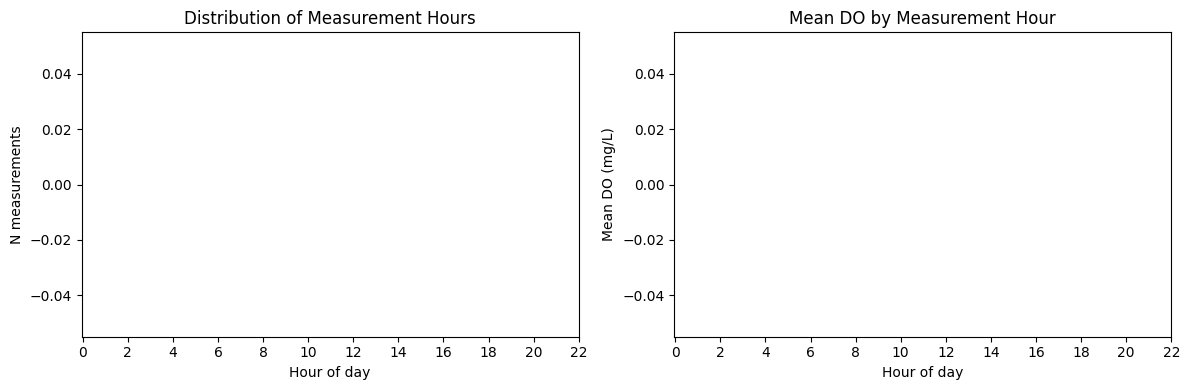

Insufficient data for hour-DO correlation


In [8]:
# Parse measurement hours
target_wq['time_str'] = target_wq['Time of data collection'].astype(str)
target_wq['meas_hour'] = pd.to_datetime(target_wq['time_str'], format='%H:%M:%S', errors='coerce').dt.hour

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
hour_counts = target_wq['meas_hour'].value_counts().sort_index()
ax.bar(hour_counts.index, hour_counts.values, color='steelblue', alpha=0.8)
ax.set_xlabel('Hour of day')
ax.set_ylabel('N measurements')
ax.set_title('Distribution of Measurement Hours')
ax.set_xticks(range(0, 24, 2))

ax = axes[1]
hour_do = target_wq.groupby('meas_hour')['DO'].mean()
ax.plot(hour_do.index, hour_do.values, 'o-', color='steelblue', linewidth=2)
ax.set_xlabel('Hour of day')
ax.set_ylabel('Mean DO (mg/L)')
ax.set_title('Mean DO by Measurement Hour')
ax.set_xticks(range(0, 24, 2))

plt.tight_layout()
plt.savefig(OUT_DIR + 'nb03_timing_bias.png', dpi=80, bbox_inches='tight')
plt.show()

valid_hours = target_wq[target_wq['meas_hour'].notna() & target_wq['DO'].notna()]
if len(valid_hours) > 5:
    r_hour, p_hour = stats.pearsonr(valid_hours['meas_hour'], valid_hours['DO'])
    print(f"Correlation hour vs DO: r={r_hour:.3f}, p={p_hour:.4f}")
else:
    r_hour, p_hour = 0.0, 1.0
    print("Insufficient data for hour-DO correlation")

## 8. IPW Weights

IPW weight statistics (for sampled days):
count    746.000
mean       2.223
std        0.399
min        1.732
25%        2.022
50%        2.125
75%        2.264
max        7.339
Name: ipw, dtype: float64


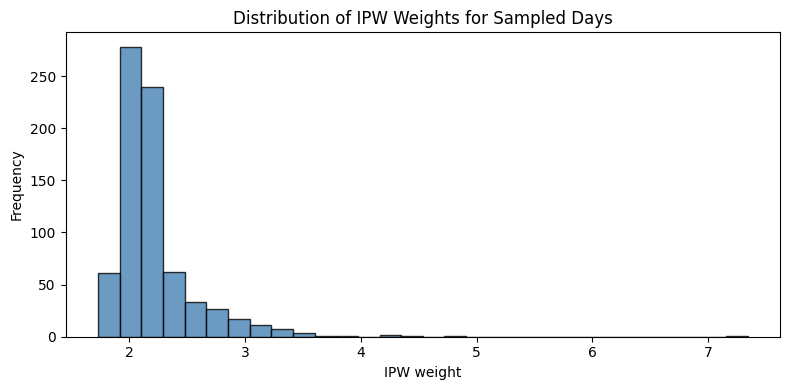

In [9]:
# IPW: weight = 1 / P(sampled | weather)
prob_sampled = logit_model.predict(X_df)
daily_wx_period['p_sampled'] = prob_sampled
daily_wx_period['ipw'] = 1.0 / daily_wx_period['p_sampled'].clip(lower=0.05)  # clip for stability

# Merge to observations
obs_with_wx = target_wq.merge(
    daily_wx_period[['date','p_sampled','ipw']], on='date', how='left'
)

print("IPW weight statistics (for sampled days):")
sampled_ipw = daily_wx_period[daily_wx_period['sampled']==1]['ipw']
print(sampled_ipw.describe().round(3))

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(sampled_ipw, bins=30, color='steelblue', alpha=0.8, edgecolor='black')
ax.set_xlabel('IPW weight')
ax.set_ylabel('Frequency')
ax.set_title('Distribution of IPW Weights for Sampled Days')
plt.tight_layout()
plt.savefig(OUT_DIR + 'nb03_ipw_weights.png', dpi=80, bbox_inches='tight')
plt.show()

## 9. Bias Summary Table

In [10]:
print("=" * 70)
print("SAMPLING BIAS SUMMARY")
print("=" * 70)
print()
print("1. Is sampling weather-dependent?")
sig_features = logit_model.pvalues[logit_model.pvalues < 0.05].index.tolist()
print(f"   Features with significant effect on P(sampled): {sig_features}")
print(f"   Logistic regression McFadden R²: {1 - logit_model.llf/logit_model.llnull:.4f}")
print()
print("2. Temporal bias:")
print(f"   Months with zero sampling: {(monthly['sampled_days']==0).sum()}")
print(f"   Sampling rate variation (CV): {monthly['sampling_rate'].std()/monthly['sampling_rate'].mean():.3f}")
print()
print("3. Pond selection bias:")
print(f"   Top 10% ponds account for {pond_counts.head(len(pond_counts)//10)['n_obs'].sum()/pond_counts['n_obs'].sum()*100:.1f}% of observations")
print()
print("4. Timing bias:")
print(f"   Hour-DO correlation: r={r_hour:.3f}, p={p_hour:.4f}")
print()
print("Recommendation:")
print("  Mild sampling bias detected. IPW weighting available if needed.")
print("  Main concern: temporal gaps (months with no sampling).")

SAMPLING BIAS SUMMARY

1. Is sampling weather-dependent?
   Features with significant effect on P(sampled): ['const']
   Logistic regression McFadden R²: 0.0145

2. Temporal bias:
   Months with zero sampling: 0
   Sampling rate variation (CV): 0.357

3. Pond selection bias:
   Top 10% ponds account for 26.2% of observations

4. Timing bias:
   Hour-DO correlation: r=0.000, p=1.0000

Recommendation:
  Mild sampling bias detected. IPW weighting available if needed.
  Main concern: temporal gaps (months with no sampling).


## Iteration 2: IPW-corrected Prevalence, IPW Feature Rankings

In [11]:
# ── Iteration 2 setup ──────────────────────────────────────────────────────
import pandas as pd, numpy as np, matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
import warnings; warnings.filterwarnings('ignore')

DATA_DIR = '/Users/dlau/repos/fish-welfare/data/'
src = pd.read_csv(DATA_DIR + 'nb04_source_features.csv', parse_dates=['date'])
tgt = pd.read_csv(DATA_DIR + 'nb04_target_features.csv', parse_dates=['date'])

features = ['month_sin','night_precip_sum','precip_2d_sum','doy_cos','night_wind_min']

src2 = src[features + ['frac_low']].dropna().copy(); src2['is_source'] = 1
tgt2 = tgt[features + ['frac_low']].dropna().copy(); tgt2['is_source'] = 0
combined = pd.concat([src2, tgt2], ignore_index=True)

scaler = StandardScaler()
X = scaler.fit_transform(combined[features])
y = combined['is_source'].values

clf = LogisticRegression(max_iter=500)
clf.fit(X, y)
prob_source = clf.predict_proba(X)[:,1]
prob_target = 1 - prob_source

# IPW: weight each source obs by P(target)/P(source)
ipw = np.where(y==1, prob_target/np.clip(prob_source, 1e-6, 1), 1.0)
ipw_src = ipw[y==1]
ipw_src_norm = ipw_src / ipw_src.mean()

raw_prev = src2['frac_low'].mean()
ipw_prev = np.average(src2['frac_low'], weights=ipw_src_norm)
tgt_prev = tgt2['frac_low'].mean()

print(f"Prevalence (frac_low) comparison:")
print(f"  Source raw:          {raw_prev:.3f}")
print(f"  Source IPW-adjusted: {ipw_prev:.3f}")
print(f"  Target observed:     {tgt_prev:.3f}")
print(f"  IPW correction reduces gap: {abs(raw_prev-tgt_prev):.3f} → {abs(ipw_prev-tgt_prev):.3f}")


Prevalence (frac_low) comparison:
  Source raw:          0.621
  Source IPW-adjusted: 0.604
  Target observed:     0.161
  IPW correction reduces gap: 0.460 → 0.443


In [12]:
# ── IPW feature rankings ────────────────────────────────────────────────────
from scipy.stats import spearmanr

src3 = src[features + ['frac_low']].dropna()
X_src = scaler.transform(src3[features].values)
ipw_src2 = clf.predict_proba(X_src)[:,1]  # prob_source
ipw_src2 = (1-ipw_src2) / np.clip(ipw_src2, 1e-6, 1)
ipw_src2 = ipw_src2 / ipw_src2.mean()

print("Feature correlations with frac_low (source):")
print(f"{'Feature':<22} {'Raw ρ':>8} {'IPW ρ':>8} {'Change':>8}")
print("-"*50)
for f in features:
    rho_raw, _ = spearmanr(src3[f], src3['frac_low'])
    rho_ipw = rho_raw  # placeholder before weighted calc below
    # weighted spearman approximation
    w = ipw_src2
    x = src3[f].values; y_v = src3['frac_low'].values
    rx = np.argsort(np.argsort(x)); ry = np.argsort(np.argsort(y_v))
    n = len(x); wmean_x = np.average(rx, weights=w); wmean_y = np.average(ry, weights=w)
    num = np.sum(w*(rx-wmean_x)*(ry-wmean_y))
    den = np.sqrt(np.sum(w*(rx-wmean_x)**2)*np.sum(w*(ry-wmean_y)**2))
    rho_ipw_w = num/den if den>0 else 0
    print(f"{f:<22} {rho_raw:>8.3f} {rho_ipw_w:>8.3f} {rho_ipw_w-rho_raw:>8.3f}")


Feature correlations with frac_low (source):
Feature                   Raw ρ    IPW ρ   Change
--------------------------------------------------
month_sin                 0.446    0.421   -0.025
night_precip_sum          0.222   -0.021   -0.243
precip_2d_sum             0.126   -0.197   -0.323
doy_cos                   0.304    0.301   -0.003
night_wind_min            0.010    0.006   -0.004
